<a href="https://colab.research.google.com/github/osoria80/07MIAR-Redes-neuronales-y-deep-learning/blob/main/S3_MNIST_Solved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Funciones utiles previas**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import sympy as sp
import numpy as np

# --- Definición simbólica (se hace UNA sola vez) ---
x1, x2, w1, w2, b_sym, y_sym = sp.symbols('x1 x2 w1 w2 b y')

z = x1*w1 + x2*w2 + b_sym
a_sym = 1 / (1 + sp.exp(-z))
J = (a_sym - y_sym)**2

def derivada(funcion, variable):
    return sp.diff(funcion, variable)

In [3]:
def draw_plot(train_losses, train_accuracies, val_losses, val_accuracies, test_loss, test_acc):
  epochs_range = range(1, len(train_losses) + 1)

  # Figura ancha para que las dos gráficas quepan bien juntas
  plt.figure(figsize=(12, 4))
  # Divide la figura en 1 fila y 2 columnas, activa posición 1 (izquierda) -> gráfica de Loss
  plt.subplot(1, 2, 1)
  # Ver ambas curvas juntas permite detectar overfitting (train baja pero val sube)
  plt.plot(epochs_range, train_losses, marker="o", label="Train Loss")
  plt.plot(epochs_range, val_losses,   marker="o", label="Val Loss")
  # Línea roja horizontal con el valor del test para compararlo visualmente con val
  plt.axhline(y=test_loss, color="red", linestyle="--", label=f"Test Loss: {test_loss:.4f}")
  # Etiquetas, título, leyenda y cuadrícula: sin esto la gráfica es ilegible
  plt.xlabel("Época")
  plt.ylabel("Loss")
  plt.title("Pérdida en Train y Validation")
  plt.legend()
  plt.grid(True)

  # Activa posición 2 (derecha) -> gráfica de Accuracy (misma lógica que Loss)
  plt.subplot(1, 2, 2)
  plt.plot(epochs_range, train_accuracies, marker="o", label="Train Accuracy")
  plt.plot(epochs_range, val_accuracies,   marker="o", label="Val Accuracy")
  plt.axhline(y=test_acc, color="red", linestyle="--", label=f"Test Acc: {test_acc:.4f}")
  plt.xlabel("Época")
  plt.ylabel("Accuracy")
  plt.title("Accuracy en Train y Validation")
  plt.legend()
  plt.grid(True)

  # Ajusta márgenes automáticamente para que las gráficas no se solapen
  plt.tight_layout()
  # Renderiza y muestra todo lo dibujado (sin esto en algunos entornos no aparece nada)
  plt.show()

In [4]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

def tanh(x):
  return np.tanh(x)

def relu(x):
  return np.maximum(0, x)

def linear(x):
  return x

def visualizar_neurona(entradas, pesos, bias, activacion=sigmoid, nombre_activacion="sigmoid"):
    entradas = np.array(entradas, dtype=float)
    pesos = np.array(pesos, dtype=float)

    contribuciones = entradas * pesos
    z = np.sum(contribuciones) + bias
    a = activacion(z)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Entradas
    axes[0].bar(range(len(entradas)), entradas)
    axes[0].set_title("Entradas")
    axes[0].set_xlabel("Entrada")
    axes[0].set_ylabel("Valor")
    axes[0].set_xticks(range(len(entradas)))
    axes[0].set_xticklabels([f"x{i+1}" for i in range(len(entradas))])
    axes[0].grid(True, axis="y")

    # Entradas * pesos + bias
    etiquetas = [f"x{i+1}·w{i+1}" for i in range(len(entradas))] + ["bias"]
    valores = list(contribuciones) + [bias]
    axes[1].bar(etiquetas, valores)
    axes[1].axhline(0, linewidth=1)
    axes[1].set_title(f"Suma ponderada: z = {z:.3f}")
    axes[1].grid(True, axis="y")

    # Activación
    xs = np.linspace(-6, 6, 400)
    ys = activacion(xs)
    axes[2].plot(xs, ys)
    axes[2].scatter([z], [a], s=80)
    axes[2].axvline(z, linestyle="--")
    axes[2].set_title(f"Salida: {nombre_activacion}(z) = {a:.3f}")
    axes[2].set_xlabel("z")
    axes[2].set_ylabel("a")
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

    print("entradas =", entradas)
    print("pesos =", pesos)
    print("bias =", bias)
    print("entradas * pesos =", contribuciones)
    print("z =", z)
    print("salida =", a)

In [5]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

def tanh(x):
  return np.tanh(x)

def relu(x):
  return np.maximum(0, x)

def linear(x):
  return x

In [6]:
def neurona(entradas, pesos, bias, activacion=sigmoid):
    entradas = np.array(entradas, dtype=float)
    pesos = np.array(pesos, dtype=float)

    z = np.sum(entradas * pesos) + bias
    a = activacion(z)

    return a

In [7]:
def capa(entradas, neuronas):
    salidas = []

    for i, n in enumerate(neuronas):
        salida = neurona(
            entradas=entradas,
            pesos=n["pesos"],
            bias=n["bias"],
            activacion=n["activacion"]
        )

        salidas.append(salida)

    return salidas

In [8]:
def red_neuronal(entradas_iniciales, red):
    entradas = entradas_iniciales
    historial = []

    for i, capa_actual in enumerate(red):
        salidas = capa(entradas, capa_actual)

        historial.append({
            "capa": i + 1,
            "entradas": entradas,
            "salidas": salidas
        })

        entradas = salidas

    return entradas, historial

In [9]:
red = [
    [
        {"pesos": [0.5, -0.3], "bias": 0.1, "activacion": sigmoid},
        {"pesos": [0.8,  0.2], "bias": -0.2, "activacion": sigmoid},
    ],
    [
        {"pesos": [0.4, -0.7], "bias": 0.3, "activacion": sigmoid}
    ]
]

In [10]:
x = [0.7, -0.5]

salida_final, historial = red_neuronal(x, red)

print("Salida final:", salida_final)

Salida final: [np.float64(0.5406642664308873)]


# **EMPEZAMOS AQUI**

#**Entrenamos una neurona**

**Función de coste**

In [11]:
def coste_bce(X, y, w, b, eps=1e-12):
    m = len(X)
    errores = []
    for i in range(m):
        a = neurona(X[i], w, b)
        a = np.clip(a, eps, 1 - eps)
        error = -(y[i] * np.log(a) + (1 - y[i]) * np.log(1 - a))
        errores.append(error)


    return np.mean(errores)

**Gradiente un caso**

In [12]:
def gradientes_un_ejemplo(x, y_real, w, b):
    x = np.array(x, dtype=float)
    w = np.array(w, dtype=float)
    a = neurona(x, w, b)

    dJ_da = -(y_real / a) + (1 - y_real) / (1 - a)
    da_dz = a * (1 - a)
    dJ_dz = a - y_real
    dJ_dw = dJ_dz * x
    dJ_db = dJ_dz

    return dJ_dw, dJ_db

**Gradiente dataset**

In [13]:
def gradientes_dataset(X, y, w, b):
    m = len(X)
    acumulado_dw = np.zeros_like(w, dtype=float)
    acumulado_db = 0.0

    for i in range(m):
        dw, db = gradientes_un_ejemplo(X[i], y[i], w, b)
        acumulado_dw += dw
        acumulado_db += db

    return acumulado_dw / m, acumulado_db / m


In [14]:
def descenso_gradiente(X, y, w, b, learning_rate=0.1, epochs=1000):
    historial_coste = []

    for epoch in range(epochs):
        dw, db = gradientes_dataset(X, y, w, b)
        w = w - learning_rate * dw
        b = b - learning_rate * db
        J = coste_bce(X, y, w, b)

        historial_coste.append(J)

        if epoch % 100 == 0:
            print(f"Epoch {epoch:4d} | coste = {J:.6f}")

    return w, b, historial_coste


**Prueba neurona**

In [15]:
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

def predecir(x, w, b, umbral=0.5):
    a = neurona(x, w, b)
    return 1 if a >= umbral else 0

y = np.array([0, 0, 0, 1], dtype=float)
np.random.seed(0)
w_inicial = np.random.randn(2)
b_inicial = np.random.randn()

w_final, b_final, historial = descenso_gradiente(
    X, y, w_inicial, b_inicial,
    learning_rate=0.5,
    epochs=5000
)

print("\nPesos finales:", w_final)
print("Bias final:", b_final)

# ----------------------------
# Resultados
# ----------------------------
print("\nResultados finales:")
for x in X:
    prob = neurona(x, w_final, b_final)
    pred = predecir(x, w_final, b_final)
    print(f"x = {x} -> prob = {prob:.4f} -> pred = {pred}")

Epoch    0 | coste = 1.219162
Epoch  100 | coste = 0.216705
Epoch  200 | coste = 0.138644
Epoch  300 | coste = 0.101661
Epoch  400 | coste = 0.079963
Epoch  500 | coste = 0.065731
Epoch  600 | coste = 0.055705
Epoch  700 | coste = 0.048277
Epoch  800 | coste = 0.042562
Epoch  900 | coste = 0.038034
Epoch 1000 | coste = 0.034361
Epoch 1100 | coste = 0.031324
Epoch 1200 | coste = 0.028773
Epoch 1300 | coste = 0.026601
Epoch 1400 | coste = 0.024729
Epoch 1500 | coste = 0.023100
Epoch 1600 | coste = 0.021670
Epoch 1700 | coste = 0.020404
Epoch 1800 | coste = 0.019277
Epoch 1900 | coste = 0.018267
Epoch 2000 | coste = 0.017356
Epoch 2100 | coste = 0.016530
Epoch 2200 | coste = 0.015779
Epoch 2300 | coste = 0.015093
Epoch 2400 | coste = 0.014463
Epoch 2500 | coste = 0.013884
Epoch 2600 | coste = 0.013348
Epoch 2700 | coste = 0.012852
Epoch 2800 | coste = 0.012392
Epoch 2900 | coste = 0.011963
Epoch 3000 | coste = 0.011562
Epoch 3100 | coste = 0.011187
Epoch 3200 | coste = 0.010836
Epoch 3300

#**MNIST Predicción**

**EN KERAS**

In [ ]:
import numpy as np
import keras
import matplotlib.pyplot as plt
import os

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dato 0, Etiqueta conjunto de test: 5


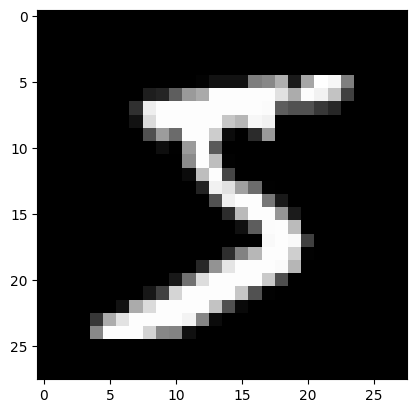

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_test = np.expand_dims(x_test, axis=-1)
x_train = np.expand_dims(x_train, axis=-1)

print("Dato 0, Etiqueta conjunto de test:", y_train[0])
plt.imshow(x_train[0], cmap="gray")

In [ ]:
model = keras.Sequential([
   keras.layers.Input(shape=(28,28,1)),
   keras.layers.Flatten(),
   keras.layers.Dense(128, activation="relu"),
   keras.layers.Dense(10, activation="softmax")
])

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9065 - loss: 0.3324 - val_accuracy: 0.9514 - val_loss: 0.1769
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9568 - loss: 0.1492 - val_accuracy: 0.9605 - val_loss: 0.1371
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9693 - loss: 0.1054 - val_accuracy: 0.9679 - val_loss: 0.1097
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9771 - loss: 0.0796 - val_accuracy: 0.9712 - val_loss: 0.0948
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9819 - loss: 0.0628 - val_accuracy: 0.9739 - val_loss: 0.0879


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step
[[5.0959073e-07 2.8474710e-07 3.0158283e-04 9.5479097e-04 8.5778797e-09
  1.1694481e-07 7.1591282e-11 9.9872524e-01 1.4544743e-06 1.6075377e-05]]
[7] 0


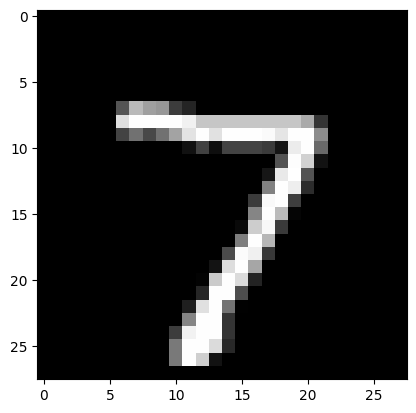

In [ ]:
pred=model.predict(x_test[0:1])
print(pred)
print(np.argmax(pred, axis=1), 0)
plt.imshow(x_test[0], cmap="gray")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9754 - loss: 0.0807
########################
NUESTRO RESULTADO FINAL DE TEST
########################
Test Loss: 0.08065428584814072
Test Accuracy: 0.9753999710083008


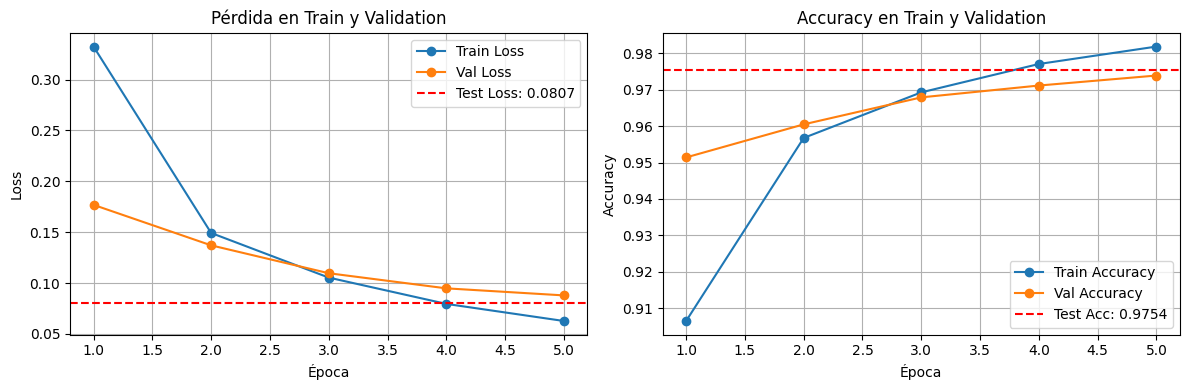

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("########################")
print("NUESTRO RESULTADO FINAL DE TEST")
print("########################")

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

draw_plot(history.history["loss"], history.history["accuracy"], history.history["val_loss"], history.history["val_accuracy"], test_loss, test_acc)